### Import Required Libraries 


In [85]:
#Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# imprt warning for cleaner output
import warnings 
warnings.filterwarnings('ignore')

### Load Dataset

In [86]:
#load dataset 
df = pd.read_csv("bank-marketing.csv")

### Data Visualization 

In [87]:
df.head() #view datase

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [88]:
df.shape #dataset size


(45211, 17)

In [89]:
df.columns # columns of dataset 

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')

In [90]:
df.dtypes #dataset cloumns type 

V1        int64
V2       object
V3       object
V4       object
V5       object
V6        int64
V7       object
V8       object
V9       object
V10       int64
V11      object
V12       int64
V13       int64
V14       int64
V15       int64
V16      object
Class     int64
dtype: object

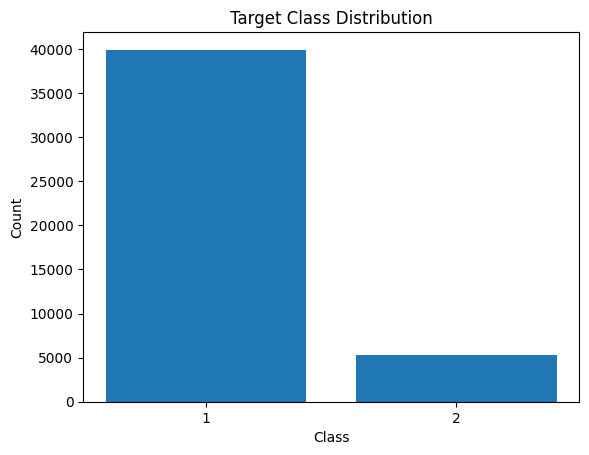

In [91]:
import matplotlib.pyplot as plt #import library 

counts = df['Class'].value_counts() #count class values 
plt.bar(counts.index.astype(str), counts.values) # shows class categoris in X-axis and count of the values in Y-axis

plt.title("Target Class Distribution") # gives the title to the bar graph 
plt.xlabel("Class") # gives the label to x-axis 
plt.ylabel("Count") # gives the label to y-axis
plt.show() # displays the bar chart 


### Data Preprocessing 

In [92]:
df['Class'] = df['Class'].replace({1: 0, 2: 1}) # replace 1-2 into 0-1  
print("Unique values in Class:", df['Class'].unique()) # print unique class value  

Unique values in Class: [0 1]


In [93]:
# import labelEncoder to convert categorical data into numerical form 
from sklearn.preprocessing import LabelEncoder

# Identify all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Encode each categorical column into numeric values
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])#convert text to numbers


In [94]:
#split features and target 
X = df.drop('Class', axis=1)
y = df['Class']

### Data Splitting

In [95]:
  # import train_test_split to split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
# Split the dataset intro training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Selection: Random Forest 

In [96]:
# Imports the Random Forest classification algorithm
from sklearn.ensemble import RandomForestClassifier
# initalize random forest with 200 decision trees and reproducible results  
rf = RandomForestClassifier(n_estimators=200, random_state=42) 
rf.fit(X_train, y_train) #train each tree
y_pred = rf.predict(X_test) #make preidictions  

### Model Evaluation 

In [97]:
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report # Imports evaluation metrics to measure model performance
print("Random Forest Accuracy:", accuracy) #calculate accuracy 
print("\nClassification Report:\n", classification_report(y_test, y_pred)) #classificatopn report

Random Forest Accuracy: 0.9016919163994249

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.64      0.42      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043

Confusion Matrix:
 [[7701  251]
 [ 638  453]]


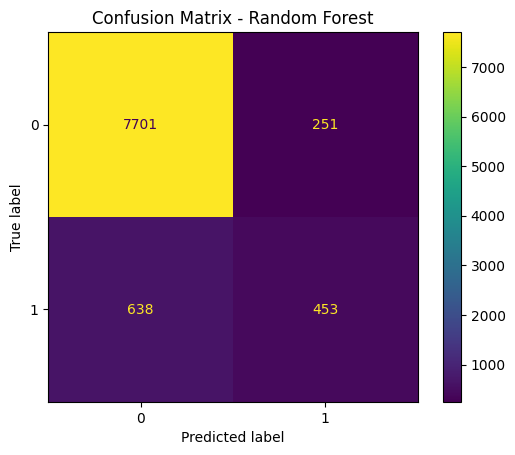

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion matrix calculation and display
# generate confusion matrix comparing acutal and predict labels 
cm = confusion_matrix(y_test, y_pred)
# Create confusion matrix display object
display = ConfusionMatrixDisplay(confusion_matrix=cm)
# plot the confusion matrix
display.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Final Visualization

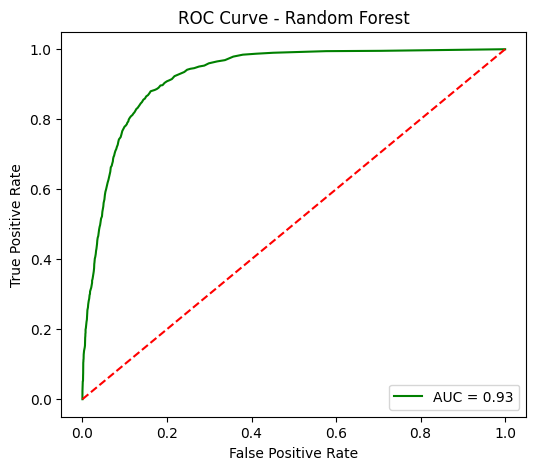

In [98]:
rf_pred_proba = rf.predict_proba(X_test)[:, 1] #predict probabilities 
# Calculate False Positive Rate and True Positive Rate
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf) # Calculate Area Under Curve

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # Random guess line
# add plot title and axis labels
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# display legend
plt.legend(loc='lower right')
#show the plot 
plt.show()